In [1]:
import pyspark
import pandas
import sklearn
import nltk
import matplotlib
import seaborn
import pymongo

print(f"✅ PySpark      : {pyspark.__version__}")
print(f"✅ Pandas       : {pandas.__version__}")
print(f"✅ Scikit-learn : {sklearn.__version__}")
print(f"✅ PyMongo      : {pymongo.__version__}")
print("✅ Toutes les librairies sont prêtes !")

✅ PySpark      : 3.5.1
✅ Pandas       : 2.3.3
✅ Scikit-learn : 1.7.2
✅ PyMongo      : 4.17.0
✅ Toutes les librairies sont prêtes !


In [2]:
import pandas as pd
import re
import os
import nltk

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split

print("✅ Imports OK")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...


✅ Imports OK


[nltk_data]   Package omw-1.4 is already up-to-date!


In [3]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

print("⏳ Chargement des données...")
df_pandas = pd.read_csv("Reviews.csv", 
    usecols=["Id", "ProductId", "UserId", "Score", "Summary", "Text"])
df_pandas = df_pandas.dropna()
print(f"✅ {len(df_pandas)} lignes chargées")

# Créer les labels
def get_label(score):
    if score < 3:
        return 0.0
    elif score == 3:
        return 1.0
    else:
        return 2.0

df_pandas['label'] = df_pandas['Score'].apply(get_label)
print("✅ Labels créés :")
print(df_pandas['label'].value_counts())

⏳ Chargement des données...
✅ 568427 lignes chargées
✅ Labels créés :
label
2.0    443777
0.0     82012
1.0     42638
Name: count, dtype: int64


In [4]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = text.lower().strip()
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return ' '.join(words)

print("⏳ Nettoyage du texte (patience ~2 minutes)...")
df_pandas['clean_text'] = df_pandas['Text'].apply(clean_text)
print("✅ Texte nettoyé !")
print(df_pandas[['Text', 'clean_text']].head(3))

⏳ Nettoyage du texte (patience ~2 minutes)...
✅ Texte nettoyé !
                                                Text  \
0  I have bought several of the Vitality canned d...   
1  Product arrived labeled as Jumbo Salted Peanut...   
2  This is a confection that has been around a fe...   

                                          clean_text  
0  bought several vitality canned dog food produc...  
1  product arrived labeled jumbo salted peanutsth...  
2  confection around century light pillowy citrus...  


In [5]:
train, temp = train_test_split(df_pandas, test_size=0.2, random_state=42)
val, test   = train_test_split(temp, test_size=0.5, random_state=42)

os.makedirs("data", exist_ok=True)
train.to_csv("data/train.csv", index=False)
val.to_csv("data/val.csv",     index=False)
test.to_csv("data/test.csv",   index=False)

print(f"✅ Train : {len(train)} lignes → data/train.csv")
print(f"✅ Val   : {len(val)} lignes   → data/val.csv")
print(f"✅ Test  : {len(test)} lignes  → data/test.csv")

✅ Train : 454741 lignes → data/train.csv
✅ Val   : 56843 lignes   → data/val.csv
✅ Test  : 56843 lignes  → data/test.csv


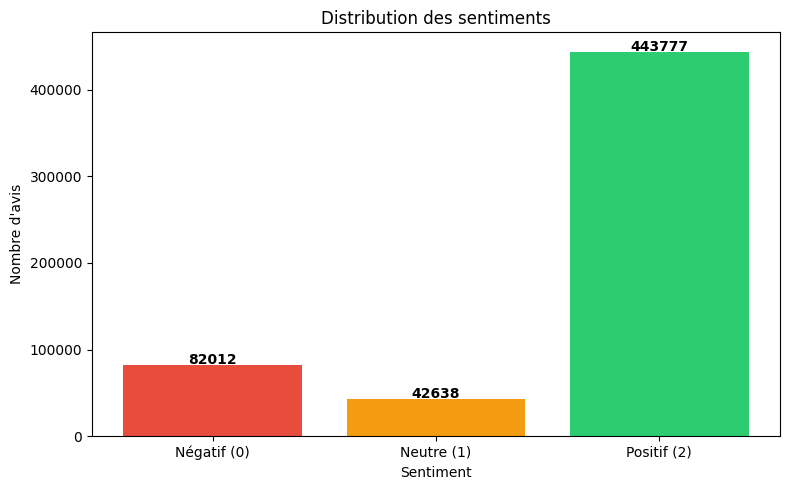

✅ Graphique 1 sauvegardé


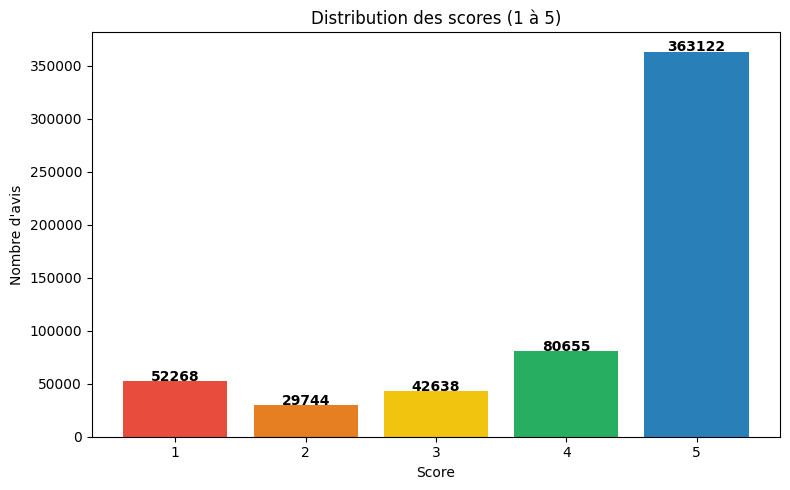

✅ Graphique 2 sauvegardé


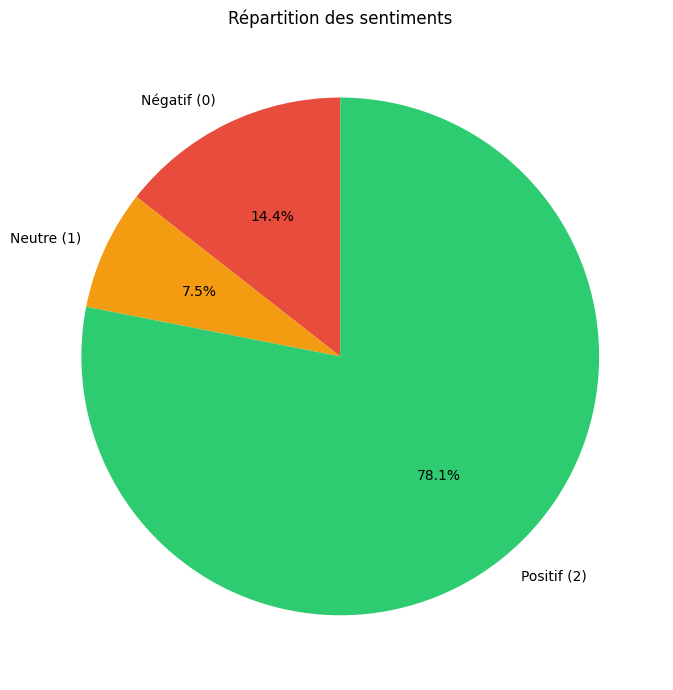

✅ Graphique 3 sauvegardé


In [6]:
# ============================================
# CELLULE 6 — Visualisation des données
# ============================================
import matplotlib.pyplot as plt
import seaborn as sns

# Graphique 1 — Distribution des labels
plt.figure(figsize=(8, 5))
labels = ['Négatif (0)', 'Neutre (1)', 'Positif (2)']
counts = df_pandas['label'].value_counts().sort_index()
colors = ['#e74c3c', '#f39c12', '#2ecc71']
plt.bar(labels, counts, color=colors)
plt.title('Distribution des sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Nombre d\'avis')
for i, v in enumerate(counts):
    plt.text(i, v + 1000, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('data/distribution_labels.png')
plt.show()
print("✅ Graphique 1 sauvegardé")

# Graphique 2 — Distribution des scores originaux
plt.figure(figsize=(8, 5))
score_counts = df_pandas['Score'].value_counts().sort_index()
colors2 = ['#e74c3c', '#e67e22', '#f1c40f', '#27ae60', '#2980b9']
plt.bar(score_counts.index, score_counts.values, color=colors2)
plt.title('Distribution des scores (1 à 5)')
plt.xlabel('Score')
plt.ylabel('Nombre d\'avis')
for i, (score, count) in enumerate(score_counts.items()):
    plt.text(score, count + 500, str(count), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('data/distribution_scores.png')
plt.show()
print("✅ Graphique 2 sauvegardé")

# Graphique 3 — Camembert des sentiments
plt.figure(figsize=(7, 7))
plt.pie(counts, labels=labels, colors=colors,
        autopct='%1.1f%%', startangle=90)
plt.title('Répartition des sentiments')
plt.tight_layout()
plt.savefig('data/camembert_sentiments.png')
plt.show()
print("✅ Graphique 3 sauvegardé")

In [7]:
# ============================================
# CELLULE 5 — Splitter et sauvegarder
# ============================================
from sklearn.model_selection import train_test_split
import os

os.makedirs("data", exist_ok=True)

# Nettoyer le texte des caractères problématiques
df_pandas['clean_text'] = df_pandas['clean_text'].str.replace('"', '', regex=False)
df_pandas['clean_text'] = df_pandas['clean_text'].str.replace('\n', ' ', regex=False)
df_pandas['clean_text'] = df_pandas['clean_text'].str.replace('\r', ' ', regex=False)

# Garder seulement les colonnes nécessaires
df_clean = df_pandas[['Id', 'ProductId', 'UserId', 'Score', 'label', 'clean_text']].copy()
df_clean['label'] = df_clean['label'].astype(float)

# Splitter 80% / 10% / 10%
train, temp = train_test_split(df_clean, test_size=0.2, random_state=42)
val, test   = train_test_split(temp, test_size=0.5, random_state=42)

# Sauvegarder proprement
train.to_csv("data/train.csv", index=False, quoting=1)
val.to_csv("data/val.csv",     index=False, quoting=1)
test.to_csv("data/test.csv",   index=False, quoting=1)

print(f"✅ Train : {len(train)} lignes")
print(f"✅ Val   : {len(val)} lignes")
print(f"✅ Test  : {len(test)} lignes")
print("✅ CSV sauvegardés correctement !")

✅ Train : 454741 lignes
✅ Val   : 56843 lignes
✅ Test  : 56843 lignes
✅ CSV sauvegardés correctement !
